In [301]:
import matplotlib.pyplot as plt
import numpy as np
import IPython.display
import scipy.io.wavfile

In [302]:


def visualiser_signal(data,rate,en_secondes=False):

    if en_secondes:
        x = np.arange(len(data)) / rate
        plt.xlabel("Temps (s)")
    else:
        x = np.arange(len(data))

        plt.xlabel("Échantillons")
    
    plt.plot(x, data)
    plt.title("Signal Audio")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.show()

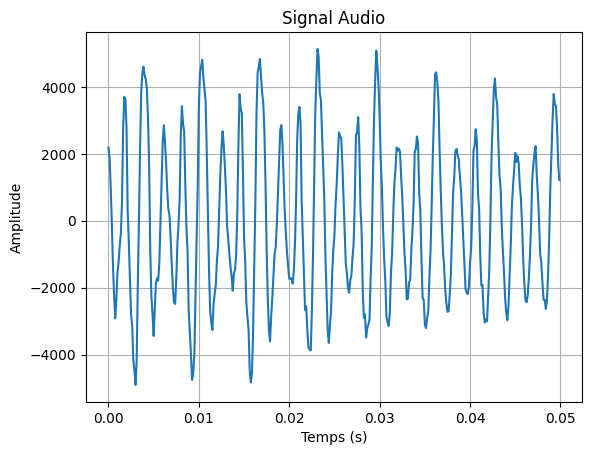

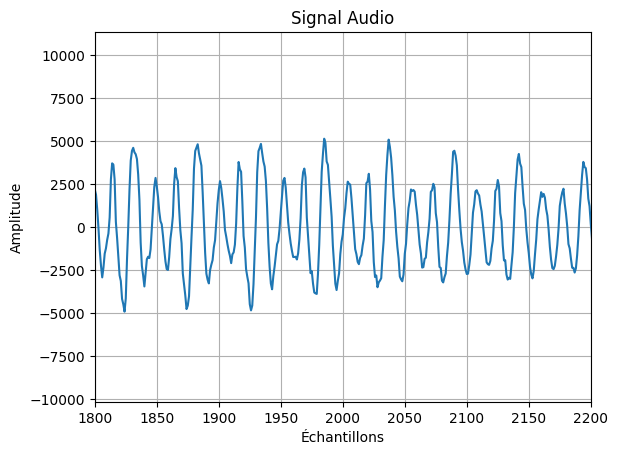

In [303]:
rate, data = scipy.io.wavfile.read("A:\Traitement Automatique de la Parole\dataset\dataset\\0_george_0.wav")

visualiser_signal(data[1800:2200:1], rate, en_secondes=True)
plt.xlim(1800, 2200)
visualiser_signal(data, rate, en_secondes=False)

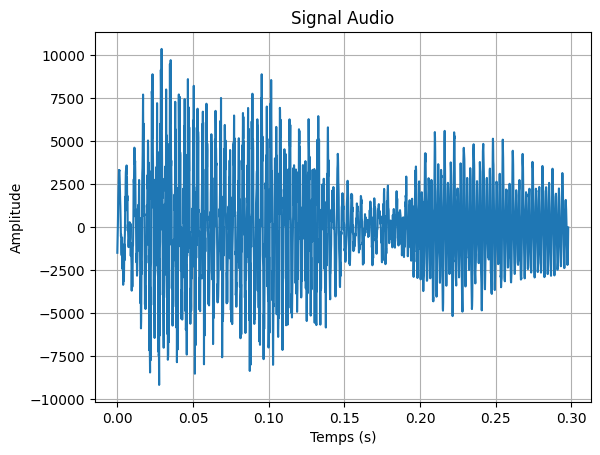

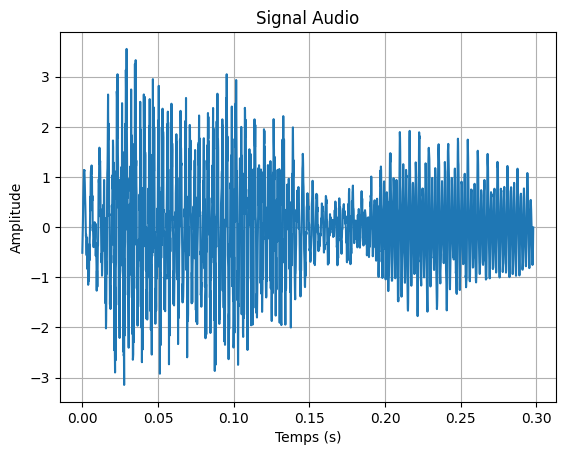

In [304]:
normalized_data = (data - np.mean(data))/ np.std(data)


visualiser_signal(data,rate,en_secondes=True)
visualiser_signal(normalized_data, rate, en_secondes=True)

In [305]:
IPython.display.Audio(normalized_data, rate=rate)


In [306]:
IPython.display.Audio(data, rate=rate)

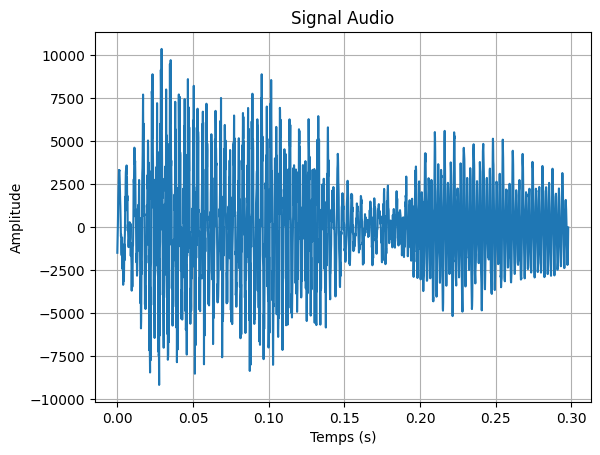

In [307]:
newrate= 8000
num = int(len(data) * newrate / rate)
resampled_data = scipy.signal.resample(data, num)
visualiser_signal(resampled_data, newrate, en_secondes=True)
IPython.display.Audio(resampled_data, rate=newrate)

In [308]:
#filtre préaccentuation x(n) = x(n) - a * x(n-1)
a = 0.98
def filtre(data,a):
    x = np.copy(data)
    x[0] = data[0]
    for i in range(1, len(data)):
        x[i] = x[i] - a * x[i-1]
    return x

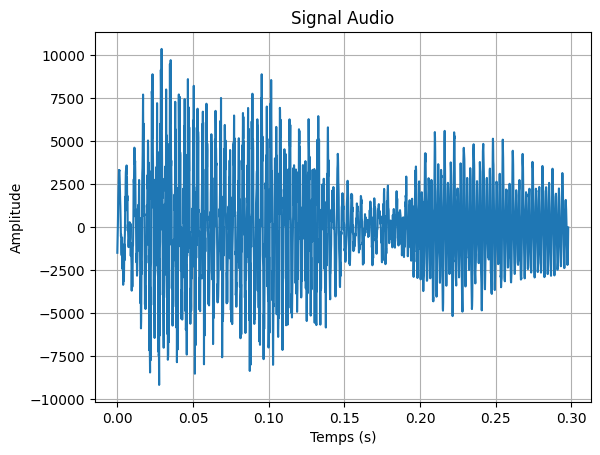

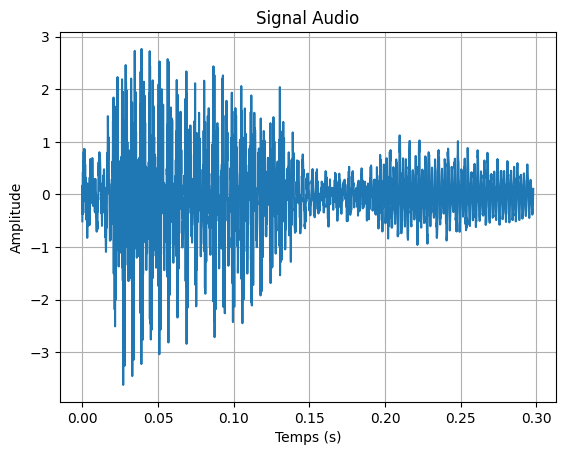

In [309]:
emphasized_signal = filtre(normalized_data,a)
visualiser_signal(data, rate, en_secondes=True)
visualiser_signal(emphasized_signal, rate, en_secondes=True)
IPython.display.Audio(emphasized_signal, rate=rate)


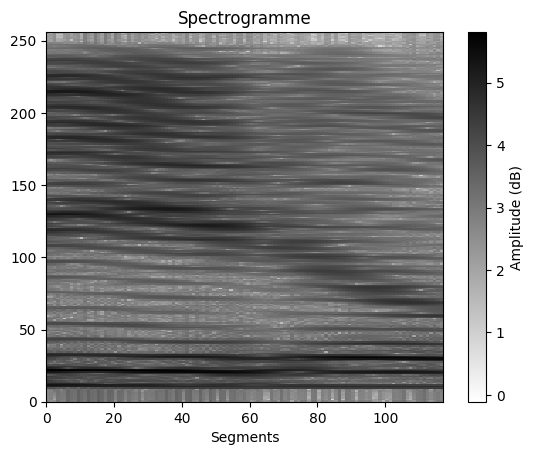

In [310]:
#fenetrage
w = 512
p = 16
def fenetrage(signal, w, p):
    fenetre = np.hamming(w)
    Segments = []
    for i in range(0, len(signal) - w, p):
        segment = signal[i:i+w] * fenetre
        Segments.append(segment)
    return np.array(Segments)
     
Frames = fenetrage(data, w, p)

frequencies =np.fft.fft(Frames)

#Spectrogramme
plt.pcolormesh(np.log10(np.abs(frequencies.T)+1e-10), cmap='gray_r')
plt.ylim(0, w//2)
plt.xlabel("Segments")
plt.title("Spectrogramme")
plt.colorbar(label="Amplitude (dB)")
plt.show()


